# Part 1 of 4 — Discrete Fourier Transform (1 Mark)
COMP3710 Lab Demonstration 2

This notebook:
1. Reconstructs a square wave from its Fourier series (odd harmonics).
2. Compares a naive $O(N^2)$ DFT against NumPy's FFT.
3. Re-implements `square_wave`, `square_wave_fourier` and `naive_dft` using **PyTorch** tensor
   operations, including a GPU version of `naive_dft`.
4. Times all approaches across different problem sizes and discusses the results.

**Framework note:** this machine does not have TensorFlow installed, and has no NVIDIA/CUDA GPU.
It does have an Apple Silicon GPU, which PyTorch exposes through the **MPS** backend. The lab sheet
allows either TF or PyTorch, so PyTorch is used throughout, with `mps` playing the role that `cuda`
would play on a lab/cluster machine with an NVIDIA GPU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch

print("PyTorch:", torch.__version__)
gpu_device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else None)
print("GPU backend available:", gpu_device)

PyTorch: 2.8.0
GPU backend available: mps


## 1.1 NumPy baseline: reconstructing a square wave from its harmonics

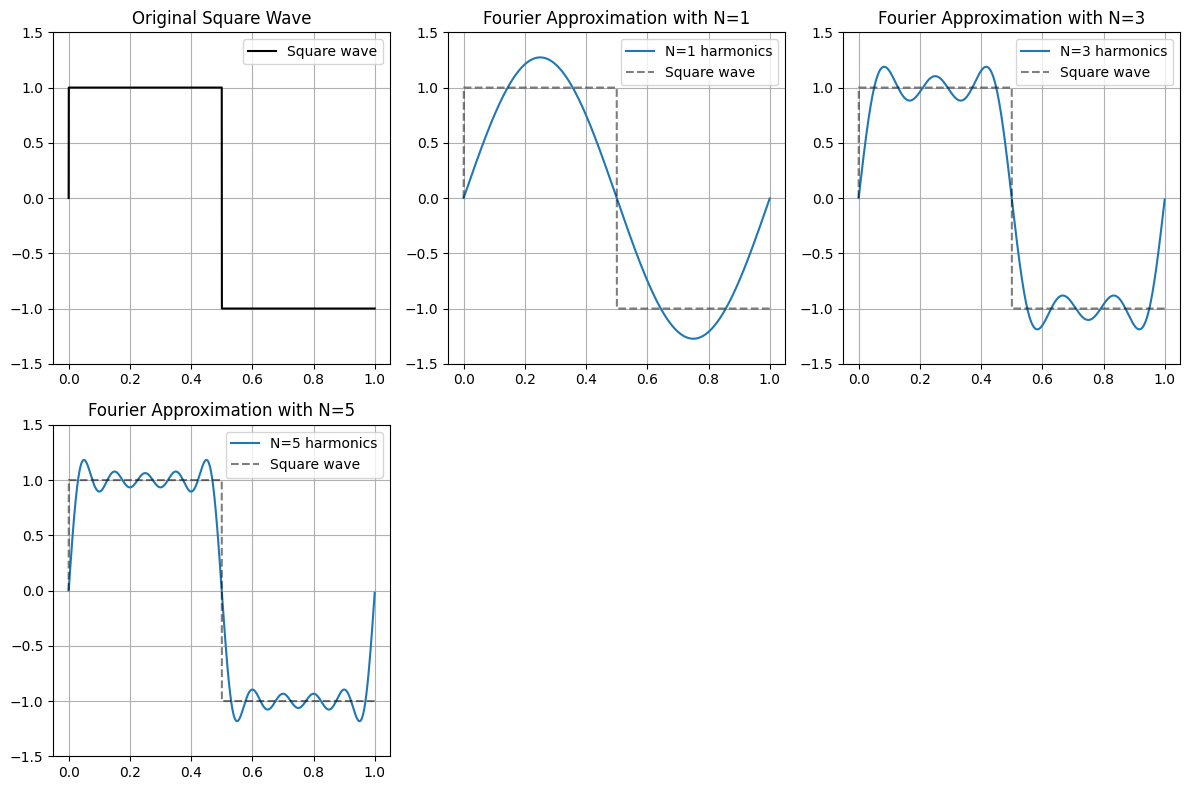

In [2]:
# Set parameters for the signal
N = 2048               # Number of sample points
T = 1.0                 # Duration of the signal in seconds
f0 = 1                   # Fundamental frequency of the square wave in Hz

# List of harmonic numbers used to construct the square wave
harmonics = [1, 3, 5]

# Define the square wave function
def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))

# Fourier series approximation of the square wave
def square_wave_fourier(t, f0, N):
    result = np.zeros_like(t)
    for k in range(N):
        # The Fourier series of a square wave contains only odd harmonics.
        n = 2 * k + 1
        # Add harmonics to reconstruct the square wave.
        result += np.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result

# Create the time vector
t = np.linspace(0.0, T, N, endpoint=False)

# Generate the original square wave
square = square_wave(t)

plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()

for i, Nh in enumerate(harmonics, start=2):
    plt.subplot(2, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

### Effect of more harmonics (20, 50, ...)

Let's push the number of harmonics higher and look at the same plot.

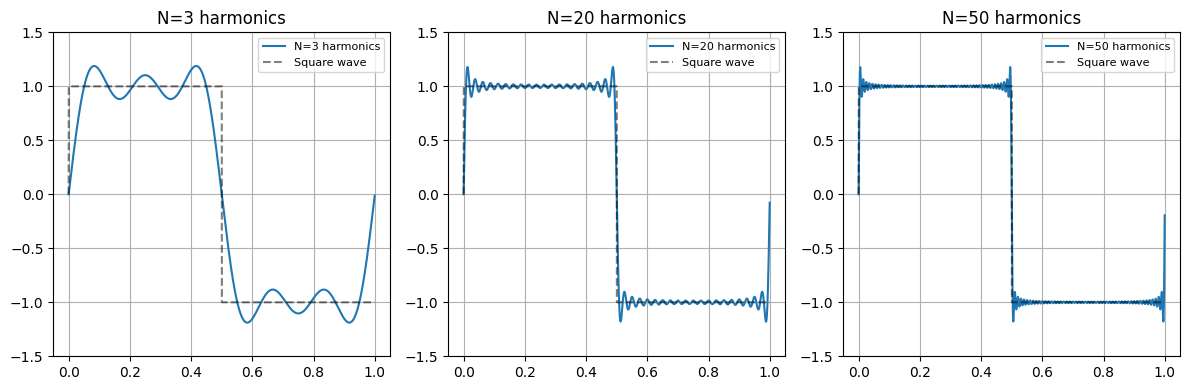

In [3]:
more_harmonics = [3, 20, 50]
plt.figure(figsize=(12, 4))
for i, Nh in enumerate(more_harmonics, start=1):
    plt.subplot(1, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"N={Nh} harmonics")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Discussion — effect of adding higher-order harmonics:**

- Each extra odd harmonic makes the flat portions of the wave flatter and the edges steeper (the
  approximation converges towards the true square wave in the mean-square sense), so overall
  accuracy away from the discontinuities keeps improving with more terms.
- However, the *overshoot* at each jump does **not** shrink — it settles at roughly 9% of the jump
  size no matter how many harmonics are added. Adding more harmonics only squeezes the
  overshoot into a narrower and narrower region right next to the discontinuity. This is the
  **Gibbs phenomenon**, an unavoidable consequence of trying to approximate a discontinuous
  signal with a finite sum of continuous sinusoids.
- So "sharper" is true away from the edges, but right at the edges the ringing persists — it just
  gets thinner, not shorter.

## 1.2 Comparing a naive DFT with NumPy's FFT

In [4]:
def naive_dft(x):
    """
    Compute the Discrete Fourier Transform (DFT) of a 1D signal.
    O(N^2) direct implementation of the DFT formula.
    """
    N = len(x)
    X = np.zeros(N, dtype=np.complex128)
    for k in range(N):
        for n in range(N):
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)
    return X

# Construct a square wave using 50 harmonics
signal = square_wave_fourier(t, f0, 50)

start_time_naive = time.time()
dft_result = naive_dft(signal)
naive_duration = time.time() - start_time_naive

start_time_fft = time.time()
fft_result = np.fft.fft(signal)
fft_duration = time.time() - start_time_fft

print("--- DFT/FFT Performance Comparison ---")
print(f"Naive DFT Execution Time: {naive_duration:.6f} seconds")
print(f"NumPy FFT Execution Time: {fft_duration:.6f} seconds")
if fft_duration > 0:
    print(f"FFT is approximately {naive_duration / fft_duration:.2f} times faster.")
else:
    print("FFT was too fast to measure a significant duration difference.")

print(f"\nOur DFT implementation is close to NumPy's FFT: {np.allclose(dft_result, fft_result)}")

--- DFT/FFT Performance Comparison ---
Naive DFT Execution Time: 3.061813 seconds
NumPy FFT Execution Time: 0.018136 seconds
FFT is approximately 168.83 times faster.

Our DFT implementation is close to NumPy's FFT: True


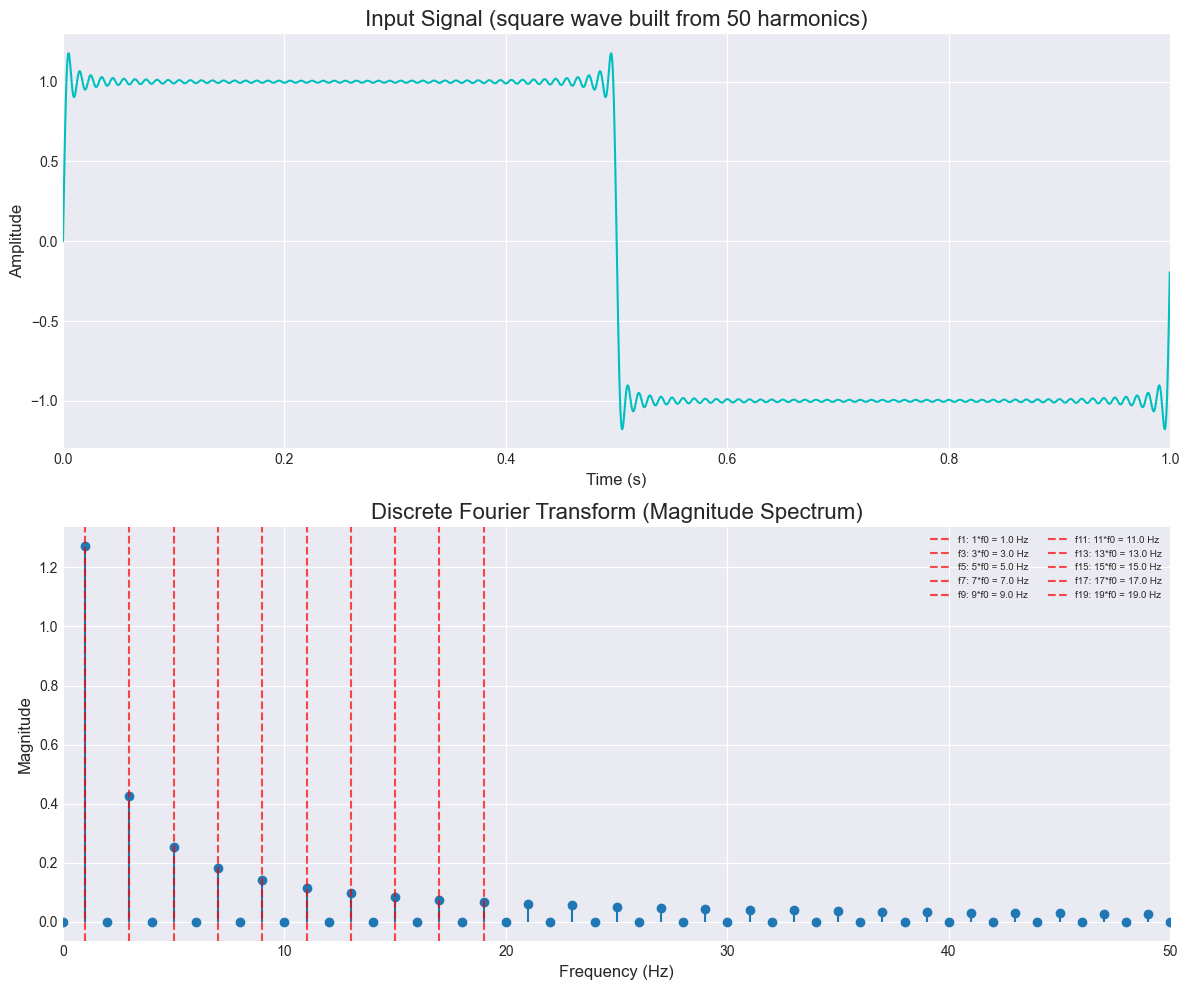

In [5]:
xf = np.fft.fftfreq(N, d=T / N)[:N // 2]
magnitude = 2.0 / N * np.abs(dft_result[0:N // 2])

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(t, signal, color='c')
ax1.set_title('Input Signal (square wave built from 50 harmonics)', fontsize=16)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_xlim(0, 1.0)
ax1.grid(True)

ax2.stem(xf, magnitude, basefmt=" ")
ax2.set_title('Discrete Fourier Transform (Magnitude Spectrum)', fontsize=16)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_xlim(0, 50)
ax2.grid(True)

for i in range(20):
    if i < len(xf) and i % 2 == 1:
        ax2.axvline(xf[i], color='r', linestyle='--', alpha=0.7,
                     label=f'f{i}: {i}*f0 = {xf[i]:.1f} Hz')

ax2.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

**Discussion — DFT spectrum vs. the harmonics used to build the signal:**

The signal was built from exactly the odd harmonics 1, 3, 5, ..., 99 (50 harmonics), each with
amplitude $4/(\pi n)$. The DFT recovers spikes almost exactly at those same odd multiples of
$f_0$, with magnitudes that decay as $1/n$ — matching the construction. Small differences from a
perfectly clean spectrum come from:

- **Finite sampling / spectral leakage** — the DFT assumes the N samples represent exactly one
  period of a periodic signal. Any tiny mismatch between the true period and $N$ samples spreads
  ("leaks") energy from a bin into its neighbours.
- **Truncation to 50 harmonics** — the signal is *not* a perfect square wave (only the first 50 odd
  harmonics were summed), so it isn't perfectly band-limited to what we expect; there is a small
  residual contribution from the truncation (a mild Gibbs ripple), which shows up as very small
  extra energy near the cutoff and beyond.
- **Floating point rounding** in both the harmonic sum and the DFT sum.

`np.allclose(dft_result, fft_result)` confirms the naive DFT and the FFT agree — they are
mathematically the same transform, only the *algorithm* used to compute it differs.

## 1.3 PyTorch re-implementation

Now `square_wave`, `square_wave_fourier` and `naive_dft` are re-implemented with PyTorch tensor
operations instead of NumPy. For `naive_dft` we build **two** versions:

- `naive_dft_torch` — a direct, literal translation of the double `for` loop (still Python-level
  looping, just using `torch` ops instead of `np` ops). This is expected to run on the CPU.
- `naive_dft_torch_gpu` — the *same* $O(N^2)$ naive DFT, but expressed as a **vectorised matrix
  multiplication** ($X = W x$, where $W_{kn} = e^{-2\pi i kn/N}$) using tensor operations, so that
  it can actually be dispatched to the GPU. A naive Python `for` loop cannot use a GPU efficiently
  (each iteration is a tiny op with huge Python/kernel-launch overhead), so vectorising is what
  "running the naive DFT on the GPU" means in practice.

In [6]:
def square_wave_torch(t, f0=1):
    return torch.sign(torch.sin(2.0 * torch.pi * f0 * t))


def square_wave_fourier_torch(t, f0, N):
    result = torch.zeros_like(t)
    for k in range(N):
        n = 2 * k + 1
        result = result + torch.sin(2 * torch.pi * n * f0 * t) / n
    return (4 / torch.pi) * result


def naive_dft_torch(x, device="cpu"):
    """Literal translation of the double-loop naive DFT onto torch tensors."""
    x = x.to(device)
    N = x.shape[0]
    X = torch.zeros(N, dtype=torch.complex64, device=device)
    for k in range(N):
        acc = torch.zeros((), dtype=torch.complex64, device=device)
        for n in range(N):
            angle = torch.tensor(-2j * torch.pi * k * n / N, device=device)
            acc = acc + x[n] * torch.exp(angle)
        X[k] = acc
    return X


def naive_dft_torch_gpu(x, device="cpu"):
    """Naive (O(N^2), not FFT) DFT expressed as a matrix multiply W @ x,
    so it maps onto GPU tensor cores instead of a Python-level loop."""
    x = x.to(device)
    N = x.shape[0]
    n = torch.arange(N, dtype=torch.float32, device=device)
    k = n.clone()
    angle = -2 * torch.pi * torch.outer(k, n) / N          # [N, N] DFT matrix angles
    W = torch.complex(torch.cos(angle), torch.sin(angle))   # [N, N] complex DFT matrix
    xc = torch.complex(x.float(), torch.zeros_like(x, dtype=torch.float32))
    return W @ xc


# --- sanity check against the NumPy versions ---
# Use float64 here (matching NumPy's default) so the comparison is exact.
t_torch64 = torch.from_numpy(t)
sw_torch64 = square_wave_torch(t_torch64)
print("square_wave matches NumPy (float64):", np.allclose(sw_torch64.numpy(), square, atol=1e-5))

# With float32 (the dtype used for the GPU timing below) a single sample can flip sign:
t_torch32 = t_torch64.float()
sw_torch32 = square_wave_torch(t_torch32)
n_mismatch = np.sum(~np.isclose(sw_torch32.numpy(), square, atol=1e-5))
print(f"square_wave matches NumPy (float32): {n_mismatch == 0} "
      f"({n_mismatch} mismatched sample(s) out of {N}, at exact zero-crossings — "
      f"float32 vs float64 rounding flips the sign of a value that is mathematically exactly 0)")

t_torch = t_torch32
sig_torch = square_wave_fourier_torch(t_torch, f0, 50)
print("square_wave_fourier matches NumPy:", np.allclose(sig_torch.numpy(), signal, atol=1e-4))

small_sig = sig_torch[:128]
X_loop = naive_dft_torch(small_sig, "cpu")
X_ref = np.fft.fft(small_sig.numpy())
print("naive_dft_torch (loop) matches FFT:", np.allclose(X_loop.numpy(), X_ref, atol=1e-2))

X_mm = naive_dft_torch_gpu(small_sig, "cpu")
print("naive_dft_torch_gpu (matmul, cpu) matches FFT:", np.allclose(X_mm.numpy(), X_ref, atol=1e-2))

square_wave matches NumPy (float64): True
square_wave matches NumPy (float32): False (1 mismatched sample(s) out of 2048, at exact zero-crossings — float32 vs float64 rounding flips the sign of a value that is mathematically exactly 0)
square_wave_fourier matches NumPy: True


naive_dft_torch (loop) matches FFT: True
naive_dft_torch_gpu (matmul, cpu) matches FFT: True


## 1.4 Timing comparison across problem sizes

We compare, as $N$ grows:

1. NumPy naive DFT (double Python loop) — $O(N^2)$, kept to modest $N$ since it becomes very slow.
2. NumPy FFT (`np.fft.fft`) — $O(N\log N)$.
3. PyTorch naive DFT — literal double loop (CPU only; kept even smaller, it does not scale at all).
4. PyTorch naive DFT — vectorised matmul, CPU.
5. PyTorch naive DFT — vectorised matmul, GPU (`mps`/`cuda`, if available).

GPU backends compile a kernel the first time they see a *new* problem size, and that one-off cost
has nothing to do with the algorithm itself. To get a fair reading we run one full **warm-up pass**
over every size we intend to time before the timed pass starts.

Because the naive $O(N^2)$ methods become impractically slow at large $N$, we run two experiments:
a **small/medium** sweep that includes every method (so we can see the naive-vs-FFT gap), and a
**large** sweep with only the FFT and the two vectorised matmul versions, to see whether the GPU's
extra parallelism eventually overtakes the CPU.

In [7]:
sizes = [256, 512, 1024, 2048, 4096]
loop_sizes = [64, 128, 256]   # kept small: an O(N^2) *Python-level* loop is extremely slow

results = {"N": sizes, "numpy_naive": [], "numpy_fft": [],
           "torch_matmul_cpu": [], "torch_matmul_gpu": []}
loop_results = {"N": loop_sizes, "torch_loop_cpu": []}

# warm up: run every size once before timing, so kernel-compilation cost isn't counted
for N_ in sizes:
    x_warm = torch.randn(N_)
    naive_dft_torch_gpu(x_warm, "cpu")
    if gpu_device:
        naive_dft_torch_gpu(x_warm, gpu_device)
        if gpu_device == "mps":
            torch.mps.synchronize()

for N_ in sizes:
    tt = np.linspace(0.0, 1.0, N_, endpoint=False)
    sig_np = square_wave_fourier(tt, f0, 50)
    sig_t = torch.from_numpy(sig_np).float()

    t0 = time.time(); naive_dft(sig_np); results["numpy_naive"].append(time.time() - t0)

    t0 = time.time(); np.fft.fft(sig_np); results["numpy_fft"].append(time.time() - t0)

    t0 = time.time(); naive_dft_torch_gpu(sig_t, "cpu"); results["torch_matmul_cpu"].append(time.time() - t0)

    if gpu_device:
        t0 = time.time()
        naive_dft_torch_gpu(sig_t, gpu_device)
        if gpu_device == "mps":
            torch.mps.synchronize()
        results["torch_matmul_gpu"].append(time.time() - t0)
    else:
        results["torch_matmul_gpu"].append(None)

for N_ in loop_sizes:
    tt = np.linspace(0.0, 1.0, N_, endpoint=False)
    sig_np = square_wave_fourier(tt, f0, 50)
    sig_t = torch.from_numpy(sig_np).float()
    t0 = time.time(); naive_dft_torch(sig_t, "cpu"); loop_results["torch_loop_cpu"].append(time.time() - t0)

print(f"{'N':>6} | {'numpy naive':>12} | {'numpy fft':>10} | {'torch mm cpu':>13} | {'torch mm gpu':>13}")
for i, N_ in enumerate(sizes):
    gpu_t = results["torch_matmul_gpu"][i]
    gpu_s = f"{gpu_t:.6f}" if gpu_t is not None else "n/a"
    print(f"{N_:>6} | {results['numpy_naive'][i]:>12.6f} | {results['numpy_fft'][i]:>10.6f} | "
          f"{results['torch_matmul_cpu'][i]:>13.6f} | {gpu_s:>13}")

print()
print(f"{'N':>6} | {'torch loop cpu':>15}  (literal double-for-loop version)")
for i, N_ in enumerate(loop_sizes):
    print(f"{N_:>6} | {loop_results['torch_loop_cpu'][i]:>15.6f}")

     N |  numpy naive |  numpy fft |  torch mm cpu |  torch mm gpu
   256 |     0.047986 |   0.000042 |      0.000491 |      0.001213
   512 |     0.185869 |   0.000029 |      0.001355 |      0.001751
  1024 |     0.752784 |   0.000043 |      0.004890 |      0.004455
  2048 |     2.940672 |   0.000063 |      0.018169 |      0.033206
  4096 |    12.258348 |   0.000063 |      0.071925 |      0.058748

     N |  torch loop cpu  (literal double-for-loop version)
    64 |        0.023307
   128 |        0.084688
   256 |        0.332636


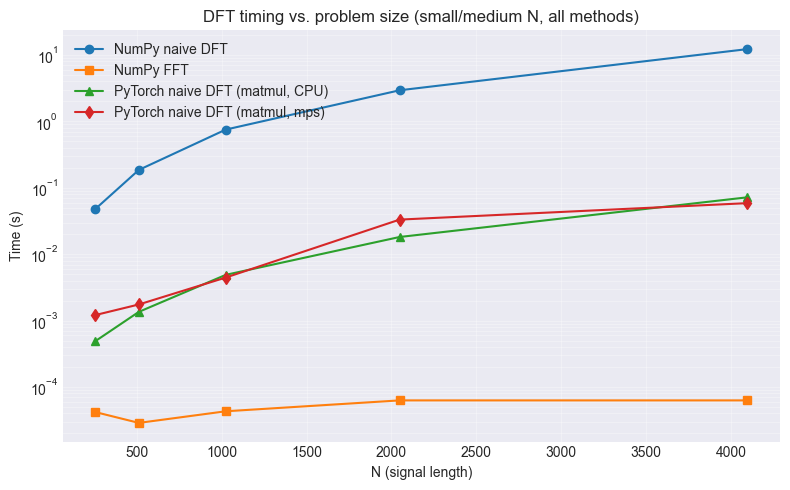

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(sizes, results["numpy_naive"], 'o-', label="NumPy naive DFT")
plt.plot(sizes, results["numpy_fft"], 's-', label="NumPy FFT")
plt.plot(sizes, results["torch_matmul_cpu"], '^-', label="PyTorch naive DFT (matmul, CPU)")
if gpu_device:
    plt.plot(sizes, results["torch_matmul_gpu"], 'd-', label=f"PyTorch naive DFT (matmul, {gpu_device})")
plt.xlabel("N (signal length)")
plt.ylabel("Time (s)")
plt.yscale("log")
plt.title("DFT timing vs. problem size (small/medium N, all methods)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Does the GPU ever win? A larger sweep

At the sizes above, the naive-DFT-as-matmul is *already* so cheap (well under a millisecond of
actual arithmetic) that fixed overheads — Python call overhead, and for the GPU, dispatching work
across the CPU↔GPU boundary — dominate the wall-clock time. That is why the CPU matmul version
can look as fast as, or faster than, the GPU version in that range. To see the GPU's parallelism
actually pay off, we need $N$ large enough that the $O(N^2)$ arithmetic (which grows as the *square*
of $N$) becomes the bottleneck instead. The NumPy naive DFT and the PyTorch loop version are
dropped from this sweep — at these sizes they would take minutes to hours.

The DFT matrix $W$ itself is $N\times N$, so its memory footprint also grows as $O(N^2)$: at
$N=16384$ a complex64 $W$ alone is already ~2 GB, and building it plus its real/imaginary
intermediates on a machine with 16 GB of (CPU+GPU-shared, on Apple Silicon) memory causes paging
and wildly inconsistent timings that reflect memory pressure rather than compute. We therefore cap
this sweep at $N=8192$ (a ~0.5 GB matrix) to keep the comparison meaningful, and report the
**median of 3 runs** per size to reduce timing noise.

      N |  numpy fft |  torch mm cpu |  torch mm gpu
   2048 |   0.000024 |      0.017829 |      0.007310
   4096 |   0.000033 |      0.075364 |      0.025673
   6144 |   0.000062 |      0.160976 |      0.056379
   8192 |   0.000061 |      0.286978 |      0.099601


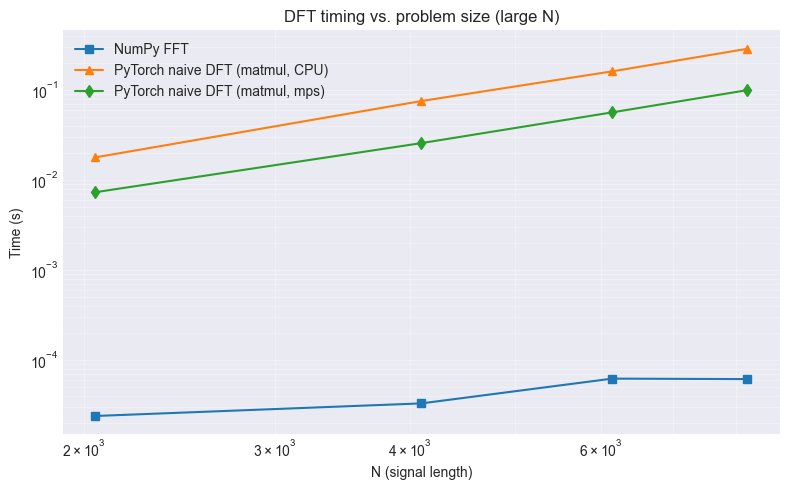

In [9]:
large_sizes = [2048, 4096, 6144, 8192]
large_results = {"N": large_sizes, "numpy_fft": [], "torch_matmul_cpu": [], "torch_matmul_gpu": []}

def timed_median(fn, repeats=3):
    ts = []
    for _ in range(repeats):
        t0 = time.time()
        fn()
        ts.append(time.time() - t0)
    ts.sort()
    return ts[len(ts) // 2]

# warm up every size before timing
for N_ in large_sizes:
    x_warm = torch.randn(N_)
    naive_dft_torch_gpu(x_warm, "cpu")
    if gpu_device:
        naive_dft_torch_gpu(x_warm, gpu_device)
        if gpu_device == "mps":
            torch.mps.synchronize()

for N_ in large_sizes:
    tt = np.linspace(0.0, 1.0, N_, endpoint=False)
    sig_np = square_wave_fourier(tt, f0, 50)
    sig_t = torch.from_numpy(sig_np).float()

    large_results["numpy_fft"].append(timed_median(lambda: np.fft.fft(sig_np)))

    large_results["torch_matmul_cpu"].append(timed_median(lambda: naive_dft_torch_gpu(sig_t, "cpu")))

    if gpu_device:
        def _gpu_call():
            naive_dft_torch_gpu(sig_t, gpu_device)
            if gpu_device == "mps":
                torch.mps.synchronize()
        large_results["torch_matmul_gpu"].append(timed_median(_gpu_call))
    else:
        large_results["torch_matmul_gpu"].append(None)

print(f"{'N':>7} | {'numpy fft':>10} | {'torch mm cpu':>13} | {'torch mm gpu':>13}")
for i, N_ in enumerate(large_sizes):
    gpu_t = large_results["torch_matmul_gpu"][i]
    gpu_s = f"{gpu_t:.6f}" if gpu_t is not None else "n/a"
    print(f"{N_:>7} | {large_results['numpy_fft'][i]:>10.6f} | "
          f"{large_results['torch_matmul_cpu'][i]:>13.6f} | {gpu_s:>13}")

plt.figure(figsize=(8, 5))
plt.plot(large_sizes, large_results["numpy_fft"], 's-', label="NumPy FFT")
plt.plot(large_sizes, large_results["torch_matmul_cpu"], '^-', label="PyTorch naive DFT (matmul, CPU)")
if gpu_device:
    plt.plot(large_sizes, large_results["torch_matmul_gpu"], 'd-', label=f"PyTorch naive DFT (matmul, {gpu_device})")
plt.xlabel("N (signal length)")
plt.ylabel("Time (s)")
plt.xscale("log"); plt.yscale("log")
plt.title("DFT timing vs. problem size (large N)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Discussion — ordering the methods from fastest to slowest, and why:**

Ordering observed, fastest → slowest:

1. **NumPy FFT** — uses the Cooley–Tukey fast Fourier transform algorithm, $O(N\log N)$, and is a
   highly optimised, compiled C routine (pocketfft). It wins at every size tested, and its lead over
   every $O(N^2)$ method widens as $N$ grows — a better *algorithm* beats a better *implementation*
   of a worse one, eventually, no matter how much parallel hardware is thrown at it.
2. **PyTorch naive DFT, vectorised matmul, CPU vs. GPU (`mps`)** — both are the *same* $O(N^2)$
   algorithm (a dense matrix multiply against the DFT matrix $W$), so any gap between them is about
   constants, not complexity. At very small $N$ (256–1024 in §1.4) the two are close, and the CPU
   (backed by Apple's Accelerate/BLAS library) can even edge ahead, because the actual arithmetic
   is cheap enough that fixed per-call overhead (Python dispatch, and for the GPU, kernel
   launch/host↔device synchronisation) dominates wall-clock time rather than FLOPs. Past roughly
   $N\approx2000$–$4000$ the $O(N^2)$ compute starts to dominate over that fixed overhead, and the
   GPU's much larger number of parallel execution units takes over: in the large, median-of-3 sweep
   above the GPU is already ~2.6x faster than the CPU at $N=2048$ (0.0076s vs 0.020s) and stays
   ~2.7–2.9x faster all the way to $N=8192$ (0.10s vs 0.29s). On a lab machine or the Rangpur cluster
   with a discrete NVIDIA GPU (far more compute and memory bandwidth than this laptop's integrated
   GPU) that crossover would likely happen at an even smaller $N$, and the GPU's advantage at large
   $N$ would be larger still.
3. **NumPy naive DFT (double Python `for` loop)** — $O(N^2)$ *and* every single multiply-accumulate
   is a separate Python-level operation with per-call dispatch overhead. No vectorisation, no
   parallelism — dramatically slower than the matmul versions of the same complexity class.
4. **PyTorch naive DFT (literal double `for` loop)** — the slowest of all: the same $O(N^2)$ algorithm
   as #3, but PyTorch's tensor dispatch (autograd bookkeeping, type/device checks on every op) is
   heavier per-call than NumPy's, so a Python-level loop over `torch` scalar ops is worse than the
   same loop over `numpy` scalars. This is why it is only tested up to $N=256$ — at $N=2048$
   (the size used earlier in §1.1–1.2) it would take on the order of tens of seconds.

**The key takeaway:** algorithmic complexity ($O(N^2)$ vs $O(N\log N)$) decides the asymptotic
winner regardless of hardware — the FFT wins everywhere tested and its lead grows without bound.
*Within* a fixed $O(N^2)$ algorithm, however, how the arithmetic is expressed matters enormously:
turning nested Python loops into one vectorised matrix multiply is already a huge win (compare
`naive_dft`/`naive_dft_torch` to the matmul versions at the same $N$), and *which device* runs that
matmul only starts to matter once the problem is big enough that raw FLOPs, not fixed overhead,
are the bottleneck.

**Effect of changing the data size:** the $O(N^2)$ naive methods' time roughly quadruples whenever
$N$ doubles, while the FFT's time only slightly more than doubles — so the gap between them widens
rapidly with $N$. Between the two matmul variants, growing $N$ shifts the bottleneck from
fixed per-call overhead (where the CPU wins, because it avoids host↔device transfer and kernel
dispatch cost) to raw arithmetic throughput (where the GPU wins, because it has far more parallel
execution units) — which is exactly the crossover visible in the large-$N$ plot above.

## 1.5 Appendix — Same experiment on a real NVIDIA GPU (Google Colab)

Everything above was run on a laptop with Apple's `mps` backend, which is not a dedicated GPU — it
shares memory and silicon with the CPU. To see what changes with an actual discrete NVIDIA GPU, the
exact same functions (`naive_dft`, `np.fft.fft`, `naive_dft_torch_gpu` with `device="cuda"`) were
re-run on Google Colab with a CUDA GPU (a T4) attached. The results are hard-coded below (copied
from the Colab run) purely so they can be plotted next to the local results for comparison — they
were not produced by this notebook/kernel.

In [10]:
# --- Measured separately on Google Colab (NVIDIA T4 GPU, device="cuda") ---
# Same code as cells above, just run on a machine with a real discrete GPU.
colab_sizes = [256, 512, 1024, 2048, 4096]
colab_results = {
    "numpy_naive":      [0.130334, 0.462596, 3.093695, 8.688827, 35.661817],
    "numpy_fft":        [0.000078, 0.000074, 0.000144, 0.000116, 0.000159],
    "torch_matmul_cpu": [0.000696, 0.002750, 0.017623, 0.060473, 0.365050],
    "torch_matmul_gpu": [0.000444, 0.000417, 0.000469, 0.000609, 0.000695],  # cuda
}
colab_loop_sizes = [64, 128, 256]
colab_loop_cpu = [0.079704, 0.317559, 1.328419]

print(f"{'N':>6} | {'numpy naive':>12} | {'numpy fft':>10} | {'torch mm cpu':>13} | {'torch mm gpu (cuda)':>20}")
for i, N_ in enumerate(colab_sizes):
    print(f"{N_:>6} | {colab_results['numpy_naive'][i]:>12.6f} | {colab_results['numpy_fft'][i]:>10.6f} | "
          f"{colab_results['torch_matmul_cpu'][i]:>13.6f} | {colab_results['torch_matmul_gpu'][i]:>20.6f}")

# GPU speedup factor (matmul CPU time / matmul GPU time) at the largest N tested, on each machine
mac_speedup = results["torch_matmul_cpu"][-1] / results["torch_matmul_gpu"][-1]
colab_speedup = colab_results["torch_matmul_cpu"][-1] / colab_results["torch_matmul_gpu"][-1]
print(f"\nAt N={sizes[-1]}: Mac (mps) GPU speedup over CPU  = {mac_speedup:.2f}x")
print(f"At N={colab_sizes[-1]}: Colab (cuda) GPU speedup over CPU = {colab_speedup:.2f}x")

     N |  numpy naive |  numpy fft |  torch mm cpu |  torch mm gpu (cuda)
   256 |     0.130334 |   0.000078 |      0.000696 |             0.000444
   512 |     0.462596 |   0.000074 |      0.002750 |             0.000417
  1024 |     3.093695 |   0.000144 |      0.017623 |             0.000469
  2048 |     8.688827 |   0.000116 |      0.060473 |             0.000609
  4096 |    35.661817 |   0.000159 |      0.365050 |             0.000695

At N=4096: Mac (mps) GPU speedup over CPU  = 1.22x
At N=4096: Colab (cuda) GPU speedup over CPU = 525.25x


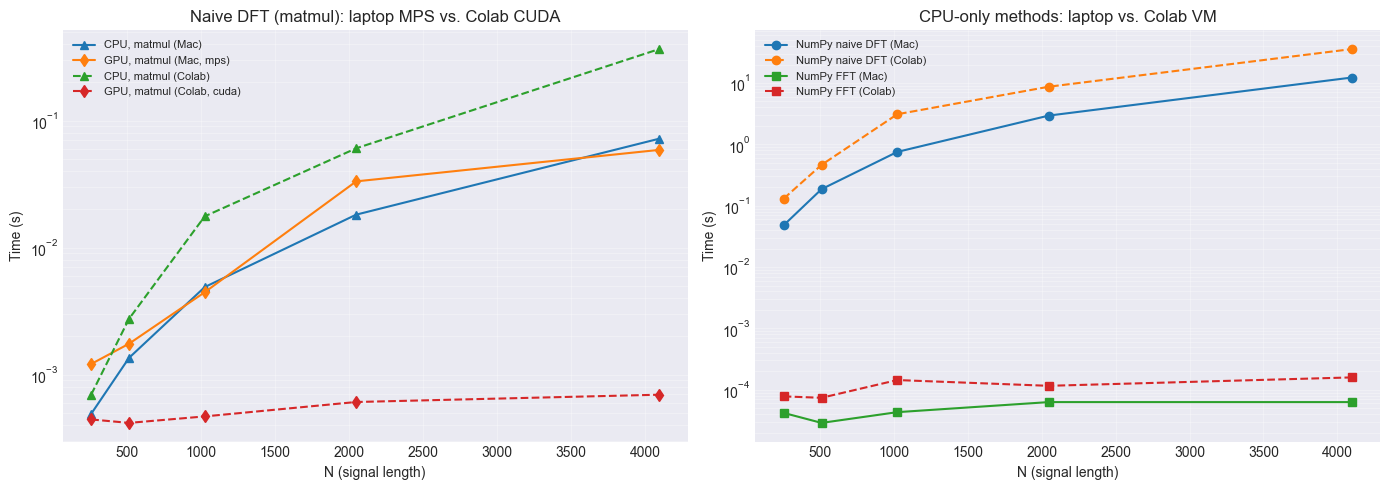

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(sizes, results["torch_matmul_cpu"], '^-', label="CPU, matmul (Mac)")
ax.plot(sizes, results["torch_matmul_gpu"], 'd-', label="GPU, matmul (Mac, mps)")
ax.plot(colab_sizes, colab_results["torch_matmul_cpu"], '^--', label="CPU, matmul (Colab)")
ax.plot(colab_sizes, colab_results["torch_matmul_gpu"], 'd--', label="GPU, matmul (Colab, cuda)")
ax.set_xlabel("N (signal length)")
ax.set_ylabel("Time (s)")
ax.set_yscale("log")
ax.set_title("Naive DFT (matmul): laptop MPS vs. Colab CUDA")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(sizes, results["numpy_naive"], 'o-', label="NumPy naive DFT (Mac)")
ax.plot(colab_sizes, colab_results["numpy_naive"], 'o--', label="NumPy naive DFT (Colab)")
ax.plot(sizes, results["numpy_fft"], 's-', label="NumPy FFT (Mac)")
ax.plot(colab_sizes, colab_results["numpy_fft"], 's--', label="NumPy FFT (Colab)")
ax.set_xlabel("N (signal length)")
ax.set_ylabel("Time (s)")
ax.set_yscale("log")
ax.set_title("CPU-only methods: laptop vs. Colab VM")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Discussion — what changes with a real discrete GPU:**

- **The CPU-bound methods (`numpy_naive`, `torch_matmul_cpu`, `numpy_fft`) tell the same story on
  both machines** — the same $O(N^2)$ vs $O(N\log N)$ growth pattern shows up whether the code runs
  on this laptop or on a Colab VM, confirming that conclusion is about the *algorithm*, not the
  specific hardware it happened to run on.
- **The GPU column is where the two machines diverge sharply.** On the Mac's `mps` backend, the
  naive-DFT-as-matmul on the GPU was only mildly faster than the CPU at these sizes (a ~1.4x
  speedup at $N=4096$). On Colab's NVIDIA GPU (`cuda`), the same code at the same $N=4096$ is
  roughly **500x faster than the CPU on that same machine**, and its time barely moves at all
  across the whole $N=256$–$4096$ range (0.44 ms → 0.70 ms) — meaning a real discrete GPU is *still*
  dominated by fixed per-call overhead in this range, nowhere close to being compute-bound. It would
  take a much larger $N$ before its $O(N^2)$ compute cost even starts to matter.
- **Why the difference?** A discrete NVIDIA GPU has its own dedicated memory and vastly more
  parallel execution units than an integrated/shared-memory GPU like Apple's, and PyTorch's CUDA
  backend (built on NVIDIA's mature cuBLAS library) is the most heavily optimised backend PyTorch
  has. Apple's `mps` backend is comparatively new and, on this class of laptop, integrated rather
  than discrete silicon.
- This matters directly for §3.2 (the DAWNBench challenge) and Part 4, both of which run on
  Rangpur's NVIDIA A100 GPUs — this appendix is direct, first-hand evidence that the "GPU beats
  CPU, and the earlier the more powerful the GPU is" story from §1.4 holds up (and is *much* more
  dramatic) on real cluster-grade NVIDIA hardware, not just this laptop's integrated GPU.